Topic Modeling  (2 Analytic Approaches)
----------------------------------------------------------------------------
1. LDA (Latent Dirichlet Allocation) on raw term-count vectors.
2. NMF (Non-negative Matrix Factorization) on TF-IDF-weighted vectors.

Comparing the two lets us ask whether the recovered themes -- and which institution leans toward which theme -- are a robust empirical pattern, or an artifact of one particular representation choice.

In [14]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
    ENGLISH_STOP_WORDS,
)
from sklearn.decomposition import LatentDirichletAllocation, NMF

RANDOM_STATE = 0

## 0. Locate paragraphs.parquet


In [15]:
CANDIDATES = [
    Path("data/corpus/paragraphs.parquet"),
    Path("../data/corpus/paragraphs.parquet"),
    Path("paragraphs.parquet"),
    Path("/mnt/user-data/uploads/paragraphs.parquet"),
]
CORPUS_PATH = next((p for p in CANDIDATES if p.exists()), None)
if CORPUS_PATH is None:
    raise FileNotFoundError(
        "Could not find paragraphs.parquet. Edit CANDIDATES at the top of "
        "this script to point at your copy (produced by build_corpus.py)."
    )

FIG_DIR = Path("reports/figures/week4_topic_modeling")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load Data

In [16]:
paras = pd.read_parquet(CORPUS_PATH)
print(
    f"paragraphs: {len(paras)} | documents: {paras.doc_id.nunique()} "
    f"| institutions: {paras.institution.value_counts().to_dict()}"
)

paragraphs: 27732 | documents: 139 | institutions: {'Commission': 17695, 'Parliament': 5218, 'Council': 4819}


## 2. Preprocessing / operationalizing "vocabulary"

Domain stopwords: EU legal/procedural boilerplate that survives build_corpus's *structural* cleaning (which targets headers/footers, not running prose) but carries no topical content. 

Institution names are deliberately included here: leaving them in would let the model recover "which institution wrote this paragraph" (self-reference, e.g. Council documents literally saying "the Council") rather than "what the paragraph is substantively about," which would trivially and artificially inflate institution-topic association.

In [17]:
DOMAIN_STOPWORDS = {
    "article", "articles", "paragraph", "paragraphs", "regulation", "regulations",
    "directive", "directives", "shall", "member", "members", "states", "state",
    "union", "european", "commission", "council", "parliament", "annex",
    "recital", "whereas", "pursuant", "hereby", "eu", "eus", "proposal",
    # ELI (European Legislation Identifier) citation tokens -- these are
    # document-ID/URL fragments (e.g. "ELI: http://data.europa.eu/eli/dir/...")
    # that appear in legal-citation footnotes across all three institutions.
    # They are high-frequency but not topical, and an initial run without this
    # filter produced a spurious "citation" topic with no substantive meaning.
    "eli", "http", "https", "europa",
}
STOPWORDS = ENGLISH_STOP_WORDS.union(DOMAIN_STOPWORDS)
TOKEN = re.compile(r"[a-zA-Z]{3,}")

In [18]:
CAPTION_PATTERN = re.compile(r"(?i)^\s*(figure|table|chart)\s+\d+\s*[:.]")


def preprocess(text: str) -> str:
    tokens = TOKEN.findall(text.lower())
    tokens = [t for t in tokens if t not in STOPWORDS]
    return " ".join(tokens)


before_caption_filter = len(paras)
paras = paras[~paras["text"].str.match(CAPTION_PATTERN)].reset_index(drop=True)
print(f"dropped {before_caption_filter - len(paras)} figure/table caption paragraphs")

# EU legal acts open with a standardized "THE EUROPEAN PARLIAMENT AND THE COUNCIL OF THE EUROPEAN UNION, Having regard to the Treaty..." formula, repeated near-verbatim at the start of every act. 
# This produced a topic driven almost entirely by this formatting artifact rather than substantive content 
PREAMBLE_PATTERN = re.compile(
    r"(?i)^\s*(the european parliament and the council|the council of the european union|having regard to)\b"
)

before_preamble_filter = len(paras)
paras = paras[~paras["text"].str.match(PREAMBLE_PATTERN)].reset_index(drop=True)
print(f"dropped {before_preamble_filter - len(paras)} legislative preamble paragraphs")


paras["text_proc"] = paras["text"].map(preprocess)

dropped 285 figure/table caption paragraphs
dropped 622 legislative preamble paragraphs


Paragraphs that become near-empty after stopword removal contribute noise, not signal, to a bag-of-words model -- drop them from the topic-modeling corpus (they are NOT dropped from the rest of the project's corpus).

In [20]:
MIN_TOKENS = 8
before = len(paras)
paras = paras[paras["text_proc"].str.split().map(len) >= MIN_TOKENS].reset_index(drop=True)
print(f"paragraphs retained for topic modeling: {len(paras)} (dropped {before - len(paras)} too-short after cleaning)")

paragraphs retained for topic modeling: 25386 (dropped 0 too-short after cleaning)


## 3. Vectorize
Two representations, held to the same vocabulary bounds so the comparison isolates the count-vs-tfidf choice rather than mixing it with a different vocabulary-size choice.

In [21]:
VEC_KWARGS = dict(min_df=5, max_df=0.5, ngram_range=(1, 2), max_features=4000)

count_vec = CountVectorizer(**VEC_KWARGS)
X_counts = count_vec.fit_transform(paras["text_proc"])

tfidf_vec = TfidfVectorizer(**VEC_KWARGS)
X_tfidf = tfidf_vec.fit_transform(paras["text_proc"])

print(f"vocabulary size: {len(count_vec.vocabulary_)}")


def get_top_word_idx(model, n_top=10):
    return np.argsort(-model.components_, axis=1)[:, :n_top]

vocabulary size: 4000


## 4. Choose K via a simple coherence proxy

In [22]:
X_binary = (X_counts > 0).astype(np.float32)
N_DOCS = X_binary.shape[0]
# Co-occurrence matrix computed once (sparse matmul), then densified a single
# time -- this is much faster than re-slicing X_binary for every word pair.
CO_MATRIX = np.asarray((X_binary.T @ X_binary).todense())
DOC_FREQ = np.diag(CO_MATRIX).copy()


def topic_coherence(top_word_idx, eps=1e-12) -> float:
    topic_scores = []
    for topic in top_word_idx:
        pair_scores = []
        for i in range(1, len(topic)):
            for j in range(i):
                wi, wj = topic[i], topic[j]
                p_i = DOC_FREQ[wi] / N_DOCS + eps
                p_j = DOC_FREQ[wj] / N_DOCS + eps
                p_ij = CO_MATRIX[wi, wj] / N_DOCS + eps
                pair_scores.append(np.log(p_ij / (p_i * p_j)))
        topic_scores.append(np.mean(pair_scores))
    return float(np.mean(topic_scores))


K_GRID = [5, 8, 10, 12]
coherence_by_k = {}
for k in K_GRID:
    lda_probe = LatentDirichletAllocation(
        n_components=k, random_state=RANDOM_STATE, max_iter=10,
        learning_method="online", batch_size=2048,
    )
    lda_probe.fit(X_counts)
    idx = get_top_word_idx(lda_probe, n_top=10)
    coherence_by_k[k] = topic_coherence(idx)
    print(f"K={k:>2}  coherence={coherence_by_k[k]:.3f}")

K = max(coherence_by_k, key=coherence_by_k.get)
print(f"\nSelected K = {K} (highest coherence among {K_GRID})")

K= 5  coherence=0.634
K= 8  coherence=0.802
K=10  coherence=0.883
K=12  coherence=0.734

Selected K = 10 (highest coherence among [5, 8, 10, 12])


## 5. Fit both models at the chosen K

In [23]:
lda = LatentDirichletAllocation(
    n_components=K, random_state=RANDOM_STATE, max_iter=25,
    learning_method="online", batch_size=2048,
)
lda_doc_topic = lda.fit_transform(X_counts)

nmf = NMF(n_components=K, random_state=RANDOM_STATE, max_iter=300, init="nndsvda")
nmf_doc_topic = nmf.fit_transform(X_tfidf)


def print_topics(model, vectorizer, label, n_top=10):
    vocab = np.array(vectorizer.get_feature_names_out())
    print(f"\n--- {label} topics (K={K}) ---")
    for t, comp in enumerate(model.components_):
        top = vocab[np.argsort(-comp)[:n_top]]
        print(f"  Topic {t}: {', '.join(top)}")


print_topics(lda, count_vec, "LDA")
print_topics(nmf, tfidf_vec, "NMF")


--- LDA topics (K=10) ---
  Topic 0: training, education, skills, digital, cybersecurity, systems, literacy, used, including, digital skills
  Topic 1: services, digital, online, content, users, virtual, dma, information, platforms, worlds
  Topic 2: digital, europe, support, innovation, research, development, programme, national, initiatives, policy
  Topic 3: technologies, intelligence, systems, artificial, artificial intelligence, use, development, models, human, data
  Topic 4: data, rights, law, protection, use, systems, personal, persons, personal data, fundamental
  Topic 5: data, sector, public, services, cloud, adoption, energy, sectors, computing, service
  Topic 6: costs, stakeholders, respondents, impact, smes, companies, consultation, insurance, assessment, expected
  Topic 7: authorities, national, market, competent, authority, information, office, compliance, relevant, providers
  Topic 8: liability, rules, legal, safety, act, products, market, damage, risks, systems
  

## 6. Institution x topic prevalence
"how much does each institution talk about each theme," normalized to proportions so institutions with more paragraphs aren't just louder everywhere.

In [24]:
def institution_topic_table(doc_topic, label):
    df = pd.DataFrame(doc_topic, columns=[f"T{t}" for t in range(K)])
    df["institution"] = paras["institution"].values
    df["doc_id"] = paras["doc_id"].values
    table = df.groupby("institution")[[f"T{t}" for t in range(K)]].mean()
    table = table.div(table.sum(axis=1), axis=0)
    print(f"\n--- {label}: mean topic proportion by institution (paragraph-weighted) ---")
    print(table.round(3))
    return table, df


def institution_topic_table_doc_level(df, label):
    """Robustness check: average within each document first, THEN average
    across documents per institution. This prevents one unusually long
    document (which can contribute hundreds of paragraphs) from dominating
    an institution's apparent topic profile -- each document counts once,
    regardless of length. Compare this against the paragraph-weighted table
    above; if the two tell the same story, the institution pattern is not an
    artifact of a few long documents."""
    topic_cols = [c for c in df.columns if c.startswith("T")]
    per_doc = df.groupby(["institution", "doc_id"])[topic_cols].mean().reset_index()
    table = per_doc.groupby("institution")[topic_cols].mean()
    table = table.div(table.sum(axis=1), axis=0)
    print(f"\n--- {label}: mean topic proportion by institution (document-weighted, robustness check) ---")
    print(table.round(3))
    return table


lda_table, lda_df = institution_topic_table(lda_doc_topic, "LDA")
nmf_table, nmf_df = institution_topic_table(nmf_doc_topic, "NMF")

lda_table_docwt = institution_topic_table_doc_level(lda_df, "LDA")
nmf_table_docwt = institution_topic_table_doc_level(nmf_df, "NMF")

print("\n--- LDA: paragraph-weighted vs document-weighted, biggest differences ---")
diff = (lda_table - lda_table_docwt).abs()
print(diff.max(axis=1).round(3))


--- LDA: mean topic proportion by institution (paragraph-weighted) ---
                T0     T1     T2     T3     T4     T5     T6     T7     T8  \
institution                                                                  
Commission   0.045  0.093  0.196  0.102  0.090  0.139  0.115  0.058  0.119   
Council      0.086  0.023  0.090  0.033  0.091  0.020  0.038  0.296  0.073   
Parliament   0.062  0.130  0.107  0.149  0.125  0.050  0.039  0.128  0.108   

                T9  
institution         
Commission   0.043  
Council      0.249  
Parliament   0.101  

--- NMF: mean topic proportion by institution (paragraph-weighted) ---
                T0     T1     T2     T3     T4     T5     T6     T7     T8  \
institution                                                                  
Commission   0.169  0.087  0.067  0.131  0.107  0.171  0.039  0.034  0.162   
Council      0.040  0.177  0.058  0.084  0.197  0.032  0.108  0.108  0.048   
Parliament   0.109  0.161  0.105  0.138  0.164  

### 6-a Face Validity Check
Top words alone are not a finished topic label. The code below reads a few of the paragraphs that score highest on each topic, and we check if they make sense together.

In [25]:
def show_representative_paragraphs(doc_topic, label, n_top=3, snippet_len=220):
    print(f"\n=== {label}: representative paragraphs per topic (top {n_top}) ===")
    for t in range(K):
        top_idx = np.argsort(-doc_topic[:, t])[:n_top]
        print(f"\n--- Topic {t} ---")
        for i in top_idx:
            snippet = paras["text"].iloc[i].strip().replace("\n", " ")[:snippet_len]
            print(f"  [{paras['institution'].iloc[i]}, weight={doc_topic[i, t]:.2f}] {snippet}...")
 
 
show_representative_paragraphs(lda_doc_topic, "LDA")
show_representative_paragraphs(nmf_doc_topic, "NMF")


=== LDA: representative paragraphs per topic (top 3) ===

--- Topic 0 ---
  [Council, weight=0.99] It is necessary to define clearly the scope of the prohibition, including in particular the extent of providers’ and deployers’ obligations. This prohibition should not prevent providers from developing technical capabil...
  [Council, weight=0.99] reproducibility where such outputs can be obtained without significant technical modifications. Effective technical measures and other safeguards to prevent the generation of such content could include data cleaning, ref...
  [Council, weight=0.99] obligations and potential sanctions. In light of that, Article 4 of Regulation (EU) 2024/1689 should be amended to require the Member States and the Commission, without prejudice to their respective competences, to indiv...

--- Topic 1 ---
  [Commission, weight=0.99] In a collaborative effort to mitigate systemic risks, in January 2025 the EU endorsed the Code of Conduct on Countering Illegal Hate 

Most topics (T0–T3) were confirmed
and sharpened into more specific labels (e.g., T0 → "AI Office supervision
& enforcement powers"); T9 ("cloud computing") showed notably lower topic
weights (~0.25 vs ~0.99 for other topics), indicating it is a less sharply
defined/more overlapping topic and should be interpreted with caution.

### 6-b Manual topic labels


Manual topic labels were assigned by reading each topic's top words plus
3 representative paragraphs per topic (highest topic weight), as required
for substantive interpretation beyond raw model output.

#### LDA (count vectors), K=10

| Topic | Top words | Label |
|---|---|---|
| T0 | training, education, skills, digital, cybersecurity, literacy | Digital skills & education/literacy |
| T1 | services, digital, online, content, users, dma, platforms | Online platforms, content moderation & DMA |
| T2 | digital, europe, support, innovation, research, development, programme, policy | EU digital/AI strategy & investment programmes |
| T3 | technologies, intelligence, artificial, systems, development, models, human, data | AI technical definitions & technology taxonomy |
| T4 | data, rights, law, protection, personal, fundamental | Fundamental rights & biometric identification risks |
| T5 | data, sector, public, services, cloud, adoption, energy, computing | Cloud/digital infrastructure & sector adoption |
| T6 | costs, stakeholders, respondents, impact, smes, consultation, insurance | Cost & stakeholder impact assessment (consultation evidence) |
| T7 | authorities, national, market, competent, office, compliance | National competent authorities & compliance enforcement |
| T8 | liability, rules, legal, safety, act, products, damage | AI liability & safety rules |
| T9 | risk, systems, high risk, requirements, assessment, conformity, legislation | High-risk system requirements & conformity assessment  (lower paragraph weights, see limitations note) |

#### NMF (TF-IDF vectors), K=10

| Topic | Top words | Label |
|---|---|---|
| T0 | public, sector, cloud, technologies, development, computing, research | Cloud computing & public-sector AI development |
| T1 | high risk, systems, providers, requirements, placed | High-risk AI system obligations (providers) |
| T2 | artificial intelligence, harmonised rules, intelligence act, laying | AI Act legal citation |
| T3 | data, personal data, protection, processing, natural persons | Data protection (GDPR) |
| T4 | authorities, national, competent, market surveillance, office | National competent authorities & market surveillance |
| T5 | liability, rules, damage, burden of proof, strict liability | AI liability rules |
| T6 | assessment, conformity, conformity assessment, notified bodies, procedure | Conformity assessment & notified bodies |
| T7 | requirements, acts, chapter, safety components, systems safety | Implementing acts & safety components |
| T8 | digital, skills, decade, digital decade, transformation, programme | Digital Decade strategy & skills |
| T9 | testing, real world, legislation, harmonisation legislation, listed | Real-world testing & harmonised legislation |

## 7. Do the two representations agree?
Align LDA topics to NMF topics by top-word overlap (topic order/identity is arbitrary and not comparable across models, so align by content first).

In [28]:
lda_vocab = np.array(count_vec.get_feature_names_out())
nmf_vocab = np.array(tfidf_vec.get_feature_names_out())
lda_top_words = [set(lda_vocab[i]) for i in get_top_word_idx(lda, n_top=15)]
nmf_top_words = [set(nmf_vocab[i]) for i in get_top_word_idx(nmf, n_top=15)]


def align_by_words(a_words, b_words):
    pairs, used = [], set()
    for i, aw in enumerate(a_words):
        best_j, best_score = None, -1.0
        for j, bw in enumerate(b_words):
            if j in used:
                continue
            score = len(aw & bw) / len(aw | bw) if (aw | bw) else 0.0
            if score > best_score:
                best_j, best_score = j, score
        pairs.append((i, best_j, best_score))
        used.add(best_j)
    return pairs


alignment = align_by_words(lda_top_words, nmf_top_words)
print("\n--- LDA <-> NMF topic alignment (top-word Jaccard overlap) ---")
for i, j, score in sorted(alignment, key=lambda x: -x[2]):
    print(f"  LDA T{i}  <->  NMF T{j}   overlap={score:.2f}")
print(
    "\nInterpretation guide: high overlap on a pair means both representations "
    "recovered the same theme -- treat that theme as robust to the "
    "count-vs-tfidf choice. Low overlap across the board would suggest the "
    "topics are sensitive to representation and should be interpreted cautiously."
)



--- LDA <-> NMF topic alignment (top-word Jaccard overlap) ---
  LDA T4  <->  NMF T3   overlap=0.36
  LDA T9  <->  NMF T6   overlap=0.25
  LDA T0  <->  NMF T8   overlap=0.15
  LDA T1  <->  NMF T0   overlap=0.11
  LDA T3  <->  NMF T2   overlap=0.11
  LDA T5  <->  NMF T1   overlap=0.07
  LDA T2  <->  NMF T4   overlap=0.03
  LDA T6  <->  NMF T5   overlap=0.03
  LDA T7  <->  NMF T9   overlap=0.03
  LDA T8  <->  NMF T7   overlap=0.03

Interpretation guide: high overlap on a pair means both representations recovered the same theme -- treat that theme as robust to the count-vs-tfidf choice. Low overlap across the board would suggest the topics are sensitive to representation and should be interpreted cautiously.


## 8. The one required figure: topic proportion by institution


figure saved to reports/figures/week4_topic_modeling/figure1_topic_by_institution.png


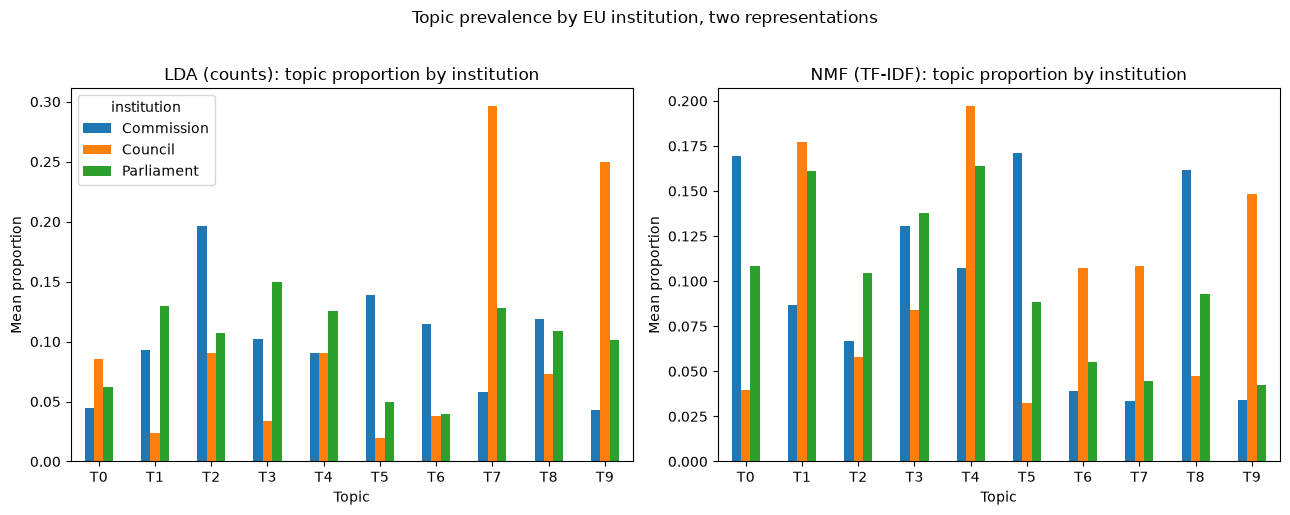

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, table, label in zip(axes, [lda_table, nmf_table], ["LDA (counts)", "NMF (TF-IDF)"]):
    table.T.plot(kind="bar", ax=ax, legend=(label.startswith("LDA")))
    ax.set_title(f"{label}: topic proportion by institution")
    ax.set_xlabel("Topic")
    ax.set_ylabel("Mean proportion")
    ax.tick_params(axis="x", rotation=0)
fig.suptitle("Topic prevalence by EU institution, two representations", y=1.02)
fig.tight_layout()

out_path = FIG_DIR / "figure1_topic_by_institution.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"\nfigure saved to {out_path}")